<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/03_select_hyperparam_for_extraction_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [ ]:
do = False # @param{type:"boolean"}
if do :
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq
    %pip install starfile -qq
    %pip install https://github.com/soft-matter/trackpy/archive/master.zip -qq

> #### ⚠ Notice
>
> You need to restart the kernel after the following step.

In [ ]:
if do :
    %pip install pycuda==2024.1
    %pip install "numpy<2.0"
    %pip install mrcfile -qq

## ⭐ Setup
You must run all codes under this category.

### ✅ Directory Settings

In [ ]:
# @title  { display-mode: "form" }

INPUT_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
IMAGE_DIR = INPUT_IMAGE_DIR
# @markdown ---

use_denoised_as_pariwise = False # @param {type : "boolean"}
dnzd_pw = use_denoised_as_pariwise
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
# @markdown ---
LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
DATASET_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_test/10017/unet_eb5_dice_CRF" # @param {type:"string"}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IMAGE_DIR = "/content/image_dir"

In [ ]:
!git clone https://github.com/phonchi/CryoParticleSegment.git

!wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
!wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
!wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
!wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

Cloning into 'CryoParticleSegment'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (270/270), done.
remote: Compressing objects: 100% (253/253), done.
remote: Total 270 (delta 141), reused 42 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (270/270), 32.01 MiB | 18.74 MiB/s, done.
Resolving deltas: 100% (141/141), done.
--2025-12-28 12:14:04--  https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17753 (17K) [text/plain]
Saving to: ‘/content/CryoParticleSegment/Modeling/convcrf.py’

/content/CryoPartic 100%[===================>]  17.34K  --.-KB/s    in 0.001s  

2025-12-28 12:14:04 (24.6 MB/s) - ‘/content/CryoParticl

In [ ]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

### ✅ Packages Handling

In [ ]:
# @title  { display-mode: "form" }
# @markdown Useful packages.

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

In [ ]:
# @title  { display-mode: "form" }
# @markdown User-defined packages.

from dataset import MicrographDataset, MicrographDatasetEvery, collate_fn

## ⭐ Main

### ✅ Setting

In [ ]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [ ]:
# @markdown Parameters.

BATCH = 8
CROP_SIZE = (512, 512)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [ ]:
crop = transforms.CenterCrop(3840)

In [ ]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
if dnzd_pw == False:
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)
else:
    dnzd_train_dir = os.path.join(DENOISED_IMAGE_DIR, 'train')
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [ ]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
if dnzd_pw == False:
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
else:
    dnzd_val_dir = os.path.join(DENOISED_IMAGE_DIR, 'val')
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [ ]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    if dnzd_pw == False:
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    else:
        dnzd_test_dir = os.path.join(DENOISED_IMAGE_DIR, 'test')
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=CROP_SIZE)

    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [ ]:
for i1, i2, i3, i4, i5 in val_loader: #test loader and reconstruct
    print(i3.dtype, i5.dtype)
    print(i3.shape, i5.shape)
    shape = i5.shape
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Evaluate

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
import starfile
import pandas as pd
import matplotlib
from PIL import Image
import cv2

def get_basename_with_uid_removed(path):
  return os.path.basename(path).split(sep='_', maxsplit=1)[-1]


def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy


In [ ]:
# @title  { vertical-output: true, display-mode: "form" }
EMPIAR_ID = 10017 # @param {type:"integer"}
RADIUS = 64 # @param {type:"integer"}
# For 10017
BORDER = 128 # @param {type:"integer"}
SIZE = 4096 # @param {type:"integer"}

In [ ]:
!cp {DATASET_DIR}/{EMPIAR_ID}/filtered_val.star .

In [ ]:
y_size = SIZE
labeled_particles = starfile.read(f"filtered_val.star")['particles']
labeled_particles = labeled_particles[['rlnMicrographName', 'rlnCoordinateX', 'rlnCoordinateY']]
labeled_particles.columns = pd.Index(['image_name', 'x_coord', 'y_coord'])
labeled_particles['image_name'] = labeled_particles['image_name'].apply(get_basename_with_uid_removed)
labeled_particles['image_name'] = labeled_particles['image_name'].apply(lambda s: s.split(".")[0])
labeled_particles['y_coord'] = y_size - labeled_particles['y_coord']
labeled_particles

,image_name,x_coord,y_coord
0,Falcon_2012_06_13-03_22_02_0,2169,1426
1,Falcon_2012_06_13-03_22_02_0,2791,1957
2,Falcon_2012_06_13-03_22_02_0,2372,475
3,Falcon_2012_06_13-03_22_02_0,2635,1047
4,Falcon_2012_06_13-03_22_02_0,3560,3965
...,...,...,...
3540,Falcon_2012_06_12-15_14_01_0,1810,1593
3541,Falcon_2012_06_12-15_14_01_0,1178,1780
3542,Falcon_2012_06_12-15_14_01_0,364,1047
3543,Falcon_2012_06_12-15_14_01_0,961,556


In [ ]:
def preprocess_and_crop(micrograph, crop_size=3840):
    processed_micrograph = simple_micrograph_preprocessing(micrograph)
    if crop_size:
        mic_width, mic_height = processed_micrograph.shape[1], processed_micrograph.shape[0]
        start_x, start_y = (mic_width - crop_size) // 2, (mic_height - crop_size) // 2
        end_x, end_y = start_x + crop_size, start_y + crop_size
        return processed_micrograph[start_y:end_y, start_x:end_x]
    else:
        return processed_micrograph

def plot_micrograph_and_labels(ax, micrograph, labels, coords):
    ax.imshow(micrograph, cmap='gray')
    ax.imshow(labels, cmap='gray', alpha=0.5)
    for x, y in coords:
        corrected_x, corrected_y = x, y
        circle = matplotlib.patches.Circle((corrected_x, corrected_y), radius=RADIUS, fill=False, color='r')
        ax.add_patch(circle)

You can specify a `crop_size` in `preprocess_and_crop()` to remove boundary artifacts during preprocessing.

In [ ]:
label_images = np.empty((0, shape[1], shape[2]), dtype=np.uint8)
gts = []

for idx, (test_image, _, _, grid, _) in enumerate(val_dataset):
    # if idx == 6:
    #     break
    name = val_filenames[idx][:-4]
    micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
    label_path = f"{LABEL_DIR}/{name}.png"
    image = Image.open(label_path)
    label_image = np.array(image)

    cropped_micrograph = preprocess_and_crop(micrograph)
    cropped_label_image = preprocess_and_crop(label_image)
    print(cropped_label_image.shape)
    label_images = np.concatenate((label_images, [cropped_label_image]), axis=0)

    locations = labeled_particles[labeled_particles['image_name'] == name]
    _, ax = plt.subplots(figsize=(12, 12))
    coords = locations[['x_coord', 'y_coord']].values - BORDER
    plot_micrograph_and_labels(ax, cropped_micrograph, cropped_label_image, coords)
    plt.show()
    print(len(coords))
    gts.append(coords)
    ##

#filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
#pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
#save_image(pred_image, pred_path)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
label_images.shape

(6, 3840, 3840)

### Score

> #### 🗒 Info
> Here, we compute the score based on the validation set. You may choose to rank the algorithms using either the F-score or mAP. Additionally, the parameter $\beta$ in the F-score can be adjusted: values of $\beta > 1$ place greater emphasis on recall over precision, while $\beta < 1$ give more weight to precision.


In [ ]:
from metrics import centers_to_boxes, calculate_iou_torchvision, evaluate_detection_raw_multiple, f_beta_score, calculate_mAP_multiple_images

In [ ]:
# Assign a default confidence score of 1.0 to all predicted boxes
default_score = 1.0
beta = 1 # @param {type:"number"}
F_score = False # @param {type:"boolean"}

---
## DT with circularity, Sphericity, Slenderness at scalar for the mean of front 50% 0.65

In [ ]:
# @title particle finding function of watershed
import cv2
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

""" EXAMPLE OF ndimage.distance_transform_edt()
a = np.array(([0,1,1,1,1],
              [0,0,1,1,1],
              [0,1,1,1,1],
              [0,1,1,1,0],
              [0,1,1,0,0]))
ndimage.distance_transform_edt(a)
array([[ 0.    ,  1.    ,  1.4142,  2.2361,  3.    ],
       [ 0.    ,  0.    ,  1.    ,  2.    ,  2.    ],
       [ 0.    ,  1.    ,  1.4142,  1.4142,  1.    ],
       [ 0.    ,  1.    ,  1.4142,  1.    ,  0.    ],
       [ 0.    ,  1.    ,  1.    ,  0.    ,  0.    ]])
"""

def calculate_shape_metrics(region):
    """Computes Sphericity, Circularity, and Inverse Slenderness."""
    area = region.area
    perimeter = region.perimeter
    if perimeter == 0: return 0, 0, 0

    circularity = (4 * np.pi * area) / (perimeter ** 2)

    d_eq = np.sqrt(4 * area / np.pi)
    d_cir = region.major_axis_length
    sphericity = d_eq / d_cir if d_cir > 0 else 0

    major = region.major_axis_length
    minor = region.minor_axis_length
    inv_slenderness = minor / major if major > 0 else 0

    return sphericity, circularity, inv_slenderness


def detect_particles_dt(prob_map_input, particle_radius=28,
                             peak_threshold_ratio=0.6, min_dist_ratio=0.4):
    """
    DT Watershed with Adaptive Shape Thresholding.

    min_dist_ratio: Min distance between 2 peaks (fraction of radius). e.g., 0.4 * 28 = 11 pixels.
    peak_threshold_ratio: multiply * with the particle_radius, and if the pixel is larger than that, it will be allow to be a candidate of the peak.

    """
    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform with scipy ndimage
    distance = ndi.distance_transform_edt(binary_mask)

    # 3. Markers Finding

    # Set the Minimum Distance of 2 markers by RADIUS x min_dist_ratio
    min_dist = int(particle_radius * min_dist_ratio)

    # Pixel DT Centre Value Threshold (to prevent finding particles that is too small)
    # e.g., If radius=28 and ratio=0.5, the peak needs to be at least of 14 pixels.
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance,                    # Send in the DT map
        min_distance=min_dist,
        labels=binary_mask,
        threshold_abs=min_peak_height # Intensity Threshold see the min_peak_height explanation
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1 # store the markers

    # 4. Watershed
    # pass the (negative) raw distance to perform the watershed.
    labels = watershed(-distance, markers, mask=binary_mask)

    # 5. Filter & Particles Candidate Extracttion
    expected_area = np.pi * (particle_radius ** 2) # use the circle area formula to assume the area of the particle

    min_area = expected_area * 0.3
    max_area = expected_area * 2
    boundary_margin = 40 # prevent from picking particles at the margin

    regions = regionprops(labels)
    candidates = []
    metrics_sp = []
    metrics_cr = []
    metrics_isd = []
    # filter out the candidate that does NOT correspond with the Area thresholding
    for region in regions:
        is_valid_area = (min_area <= region.area <= max_area)

        if is_valid_area:
            sp, cr, isd = calculate_shape_metrics(region)
            candidates.append({'region': region, 'sp': sp, 'cr': cr, 'isd': isd})
            metrics_sp.append(sp)
            metrics_cr.append(cr)
            metrics_isd.append(isd)

    if not candidates:
        return []

    # 6. Calculate Dynamic Thresholds of circularity, sphericity, slenderness
    def get_adaptive_range(metric_list):
            """
            Calculates both Lower and Upper adaptive thresholds.

            Lower Bound (For 'Higher is Better' quality):
            - Uses Top 50% Mean (Good particles).
            - Stricter = Higher Value (np.max).

            Upper Bound (For outlier/anomaly detection):
            - Uses Lower 50% Mean (Background/Noise reference).
            - Stricter = Lower Value (np.min).
            """
            if not metric_list: return 0.0, float('inf')

            # 1. Calculate Statistics
            max_val = np.max(metric_list)
            min_val = np.min(metric_list)
            data_range = max_val - min_val

            # Sort for quantiles
            sorted_vals = sorted(metric_list)
            n = len(sorted_vals)
            mid = max(1, n // 2)

            # ---------------------------------------------------------
            # A. Lower Threshold (Min Acceptable Quality)
            # ---------------------------------------------------------
            # Use Top 50% (The "Good" half)
            top_half = sorted_vals[mid:]
            mean_top50 = np.mean(top_half)

            # Logic: Mean - (Range * 0.5)
            calc_lower = mean_top50 - (data_range * 0.8)
            # Safety: Don't go below 80% of the good mean
            floor_lower = mean_top50 * 0.7

            # Take the STRICTER (Higher) bound
            thresh_min = np.max([calc_lower, floor_lower])

            # ---------------------------------------------------------
            # B. Upper Threshold (Max Acceptable / Outlier Cutoff)
            # ---------------------------------------------------------
            # Use Lower 50% (The "Bad" or "Small" half) - As requested
            lower_half = sorted_vals[:mid]
            mean_lower50 = np.mean(lower_half)

            # Logic: Mean + (Range * 0.5)
            # "instead of minus add it back"
            calc_upper = mean_lower50 + (data_range * 0.8) # perhaps 0.7 ~ 0.85 will be better (need more trial)

            # Safety: Don't go above 120% of the lower mean
            # "min with 1.2mean of lower 50%"
            ceiling_upper = mean_lower50 * 1.4

            # Take the Looser (Lower) bound
            thresh_max = np.max([calc_upper, ceiling_upper])

            # Sanity Check: Ensure min <= max. If crossed, rely on min.
            if thresh_max < thresh_min:
                thresh_max = float('inf')

            return thresh_min, thresh_max

    # The adaptive cutoff values for Sphericity, Circularity, and Inv-Slenderness.
    min_sp, max_sp = get_adaptive_range(metrics_sp)
    min_cr, max_cr = get_adaptive_range(metrics_cr)
    min_isd, max_isd = get_adaptive_range(metrics_isd)

    show_plots = True
    if show_plots:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        metrics = [metrics_sp, metrics_cr, metrics_isd]
        titles = ['Sphericity', 'Circularity', 'Inv-Slenderness']
        bounds = [[min_sp, max_sp], [min_cr, max_cr], [min_isd, max_isd]]

        for i in range(3):
            axes[i].hist(metrics[i], bins=20, color='gray', alpha=0.5)
            axes[i].axvline(bounds[i][0], color='red', linestyle='--', label='Min')
            axes[i].axvline(bounds[i][1], color='blue', linestyle='--', label='Max')
            axes[i].set_title(titles[i])
            if i == 0: axes[i].legend()
        plt.suptitle(f"Adaptive Thresholds for Current Image (N={len(candidates)})")
        plt.show()

    # 7. Final Selection
    valid_particles = []
    for cand in candidates:
        # Must pass ALL adaptive shape thresholds
        if (min_sp <= cand['sp'] <= max_sp and
            min_cr <= cand['cr'] <= max_cr and
            min_isd <= cand['isd'] <= max_isd):

            region = cand['region']
            cy, cx = region.centroid

            if (cx < boundary_margin or cx > (width - boundary_margin) or
                cy < boundary_margin or cy > (height - boundary_margin)):
                continue

            score = prob_map[int(cy), int(cx)]
            valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

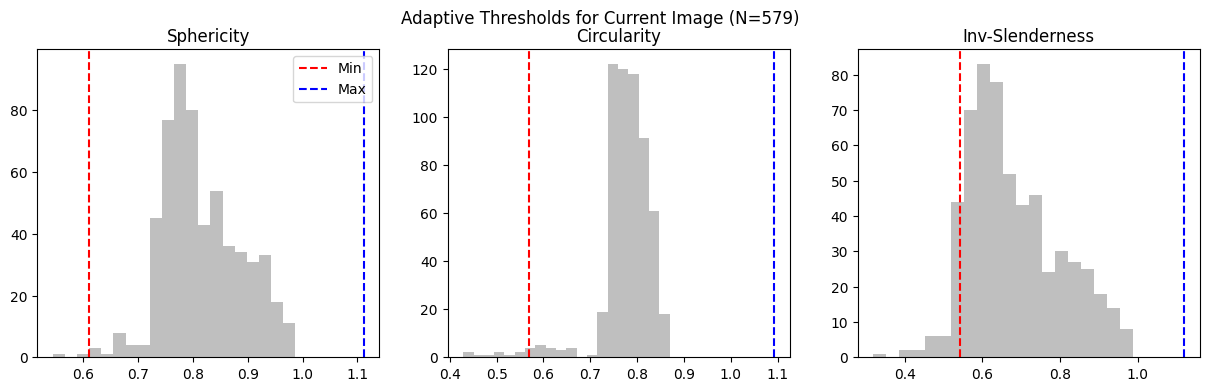

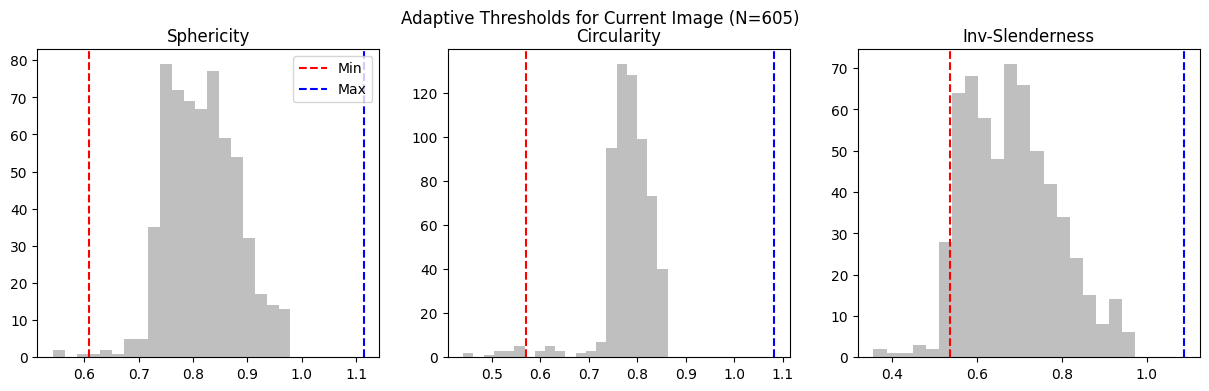

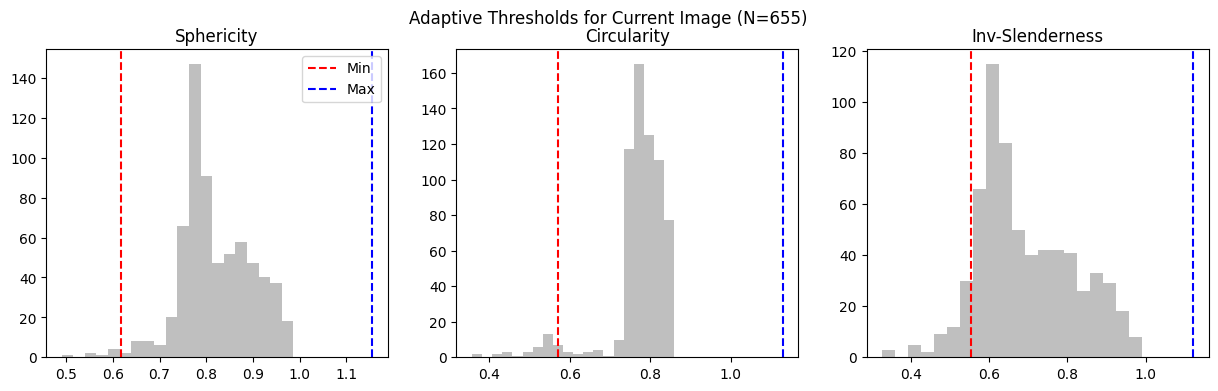

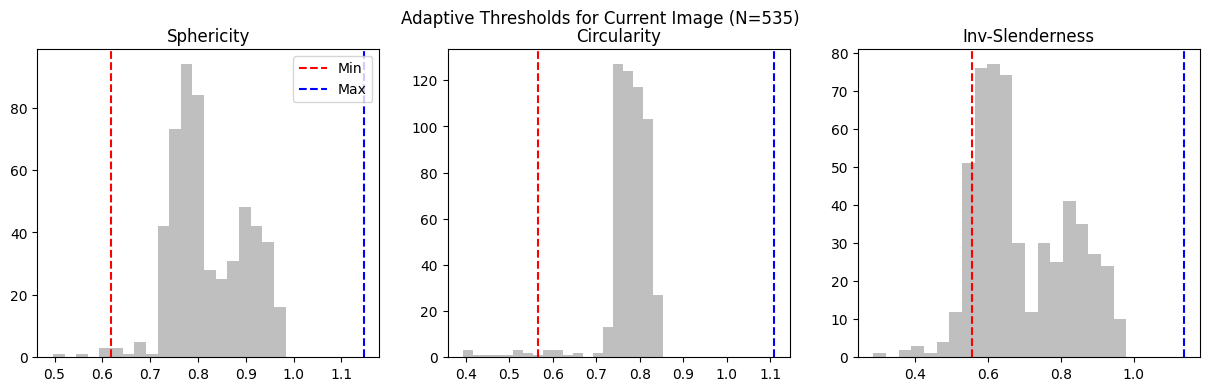

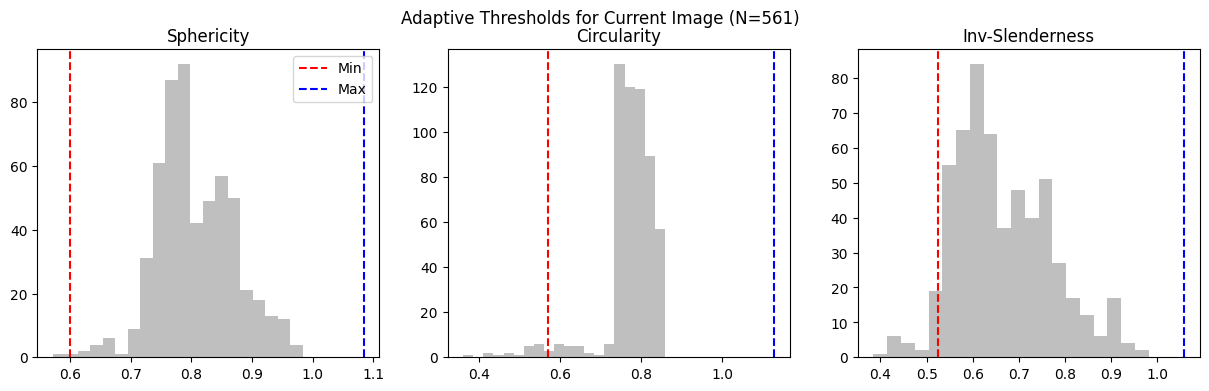

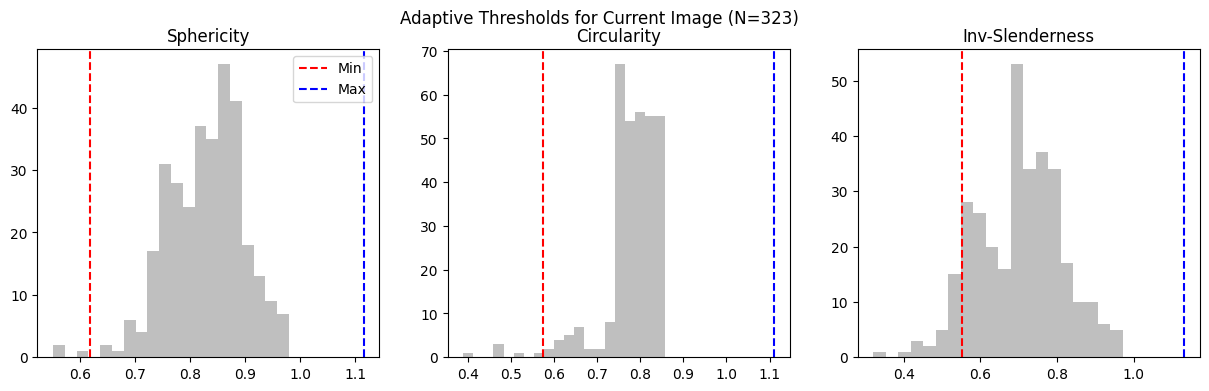

In [ ]:
radius = RADIUS

watershed_config = [0.4, 0.8]
watershed_list = []

for img in label_images:
    particles = detect_particles_dt(
        img,
        particle_radius=radius,
        peak_threshold_ratio=watershed_config[0],
        min_dist_ratio=watershed_config[1]
    )
    watershed_list.append(particles)

In [ ]:
for idx, (test_image, _, _, grid, _) in enumerate(val_dataset):
    name = val_filenames[idx][:-4]
    micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
    label_path = f"{LABEL_DIR}/{name}.png"
    image = Image.open(label_path)
    label_image = np.array(image)

    cropped_micrograph = preprocess_and_crop(micrograph)
    cropped_label_image = preprocess_and_crop(label_image)

    _, ax = plt.subplots(figsize=(12, 12))
    preds = watershed_list[idx]
    coords = [p[:2] for p in preds]
    plot_micrograph_and_labels(ax, cropped_micrograph, cropped_label_image, coords)
    plt.show()

---

### adjusted_Z_score_thresholding_range

In [ ]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

def detect_particles_dt(prob_map_input, particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):
    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform
    distance = ndi.distance_transform_edt(binary_mask)

    # 3. Markers Finding
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance,
        min_distance=min_dist,
        labels=binary_mask,
        threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)

    # 5. Extract Candidate Metrics
    expected_area = np.pi * (particle_radius ** 2)
    min_area, max_area = expected_area * 0.3, expected_area * 2.0

    regions = regionprops(labels)
    candidates = []
    m_sp, m_cr, m_isd = [], [], []

    for region in regions:
        if min_area <= region.area <= max_area:
            sp, cr, isd = calculate_shape_metrics(region)
            candidates.append({'region': region, 'metrics': (sp, cr, isd)})
            m_sp.append(sp); m_cr.append(cr); m_isd.append(isd)

    if not candidates: return []

    # 6. Statistical Thresholding (Modified Z-Score / MAD)
    #  MAD statistics thresholding
    def get_mad_range(data, z_thresh=3.0):
        if not data: return 0.0, 1.0
        arr = np.array(data)
        med = np.median(arr)
        mad = np.median(np.abs(arr - med))
        if mad == 0: return np.min(arr), np.max(arr)

        # Calculate bounds based on 3 median absolute deviations
        low = med - (z_thresh * mad / 0.6745)
        high = med + (z_thresh * mad / 0.6745)
        return max(0.0, low), min(1.0, high)

    thresh_sp = get_mad_range(m_sp)
    thresh_cr = get_mad_range(m_cr)
    thresh_isd = get_mad_range(m_isd)

    # 7. Auto-Visualization
    # changed) added automatic plotting of the current image's metric distributions
    if show_plots:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        metrics = [m_sp, m_cr, m_isd]
        titles = ['Sphericity', 'Circularity', 'Inv-Slenderness']
        bounds = [thresh_sp, thresh_cr, thresh_isd]

        for i in range(3):
            axes[i].hist(metrics[i], bins=20, color='gray', alpha=0.5)
            axes[i].axvline(bounds[i][0], color='red', linestyle='--', label='Min')
            axes[i].axvline(bounds[i][1], color='blue', linestyle='--', label='Max')
            axes[i].set_title(titles[i])
            if i == 0: axes[i].legend()
        plt.suptitle(f"Adaptive Thresholds for Current Image (N={len(candidates)})")
        plt.show()

    # 8. Final Selection
    valid_particles = []
    boundary_margin = 40
    for cand in candidates:
        sp, cr, isd = cand['metrics']
        if (thresh_sp[0] <= sp <= thresh_sp[1] and
            thresh_cr[0] <= cr <= thresh_cr[1] and
            thresh_isd[0] <= isd <= thresh_isd[1]):

            region = cand['region']
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

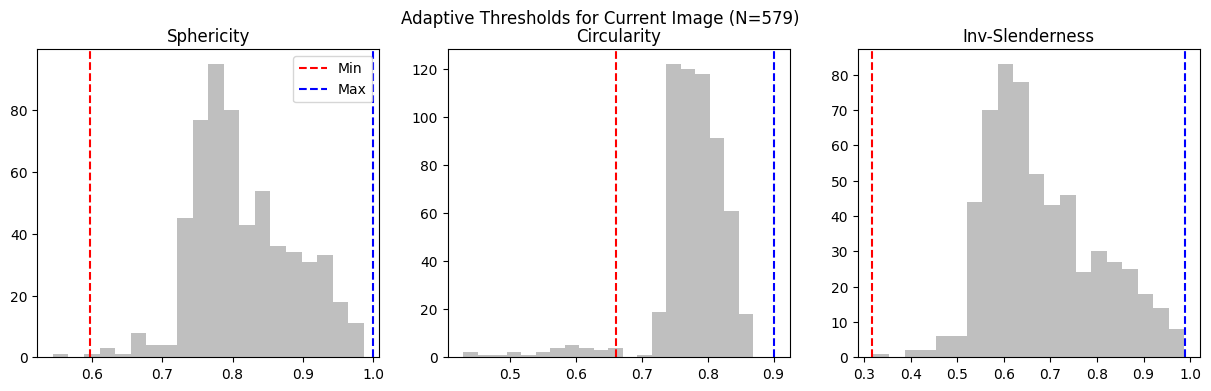

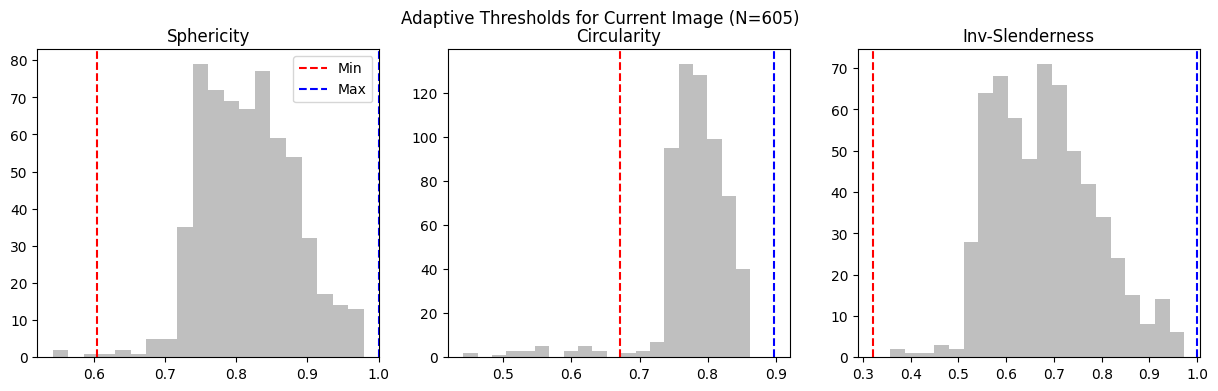

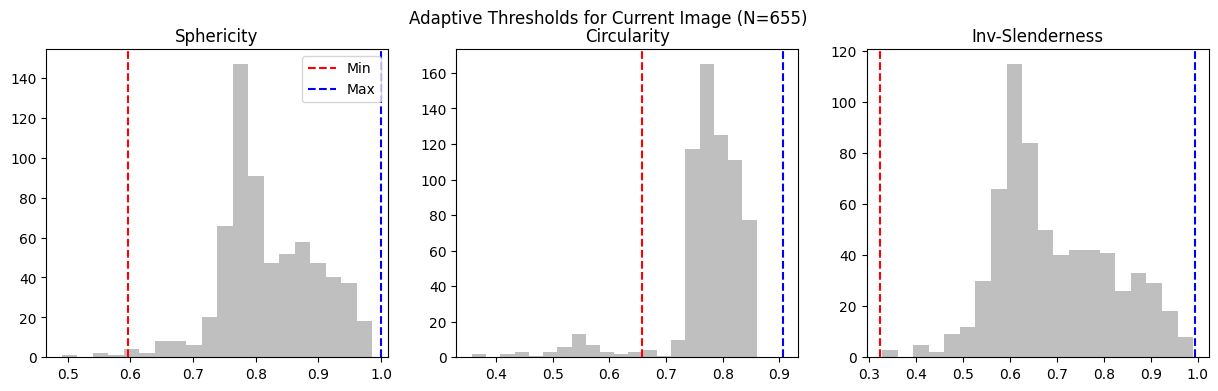

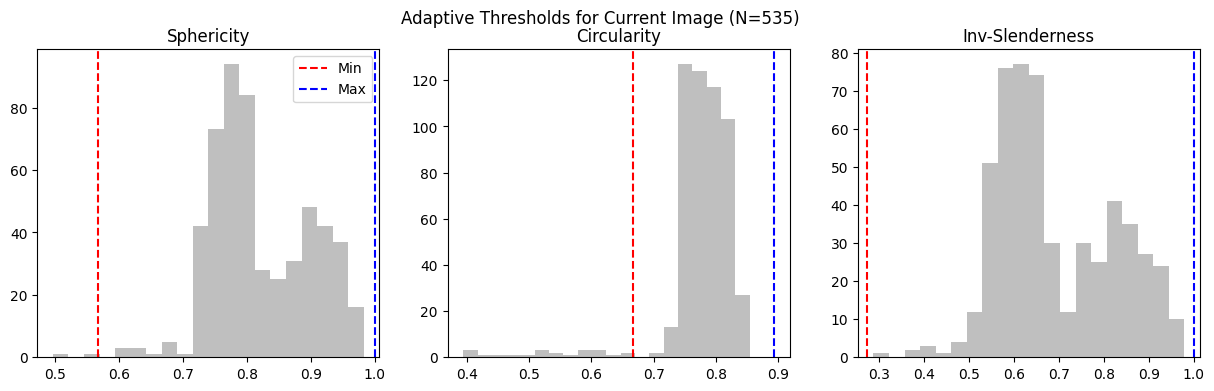

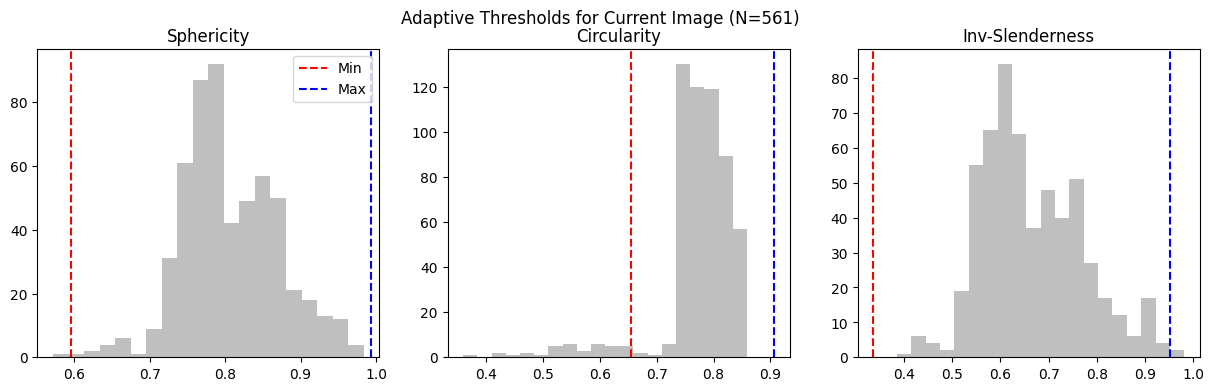

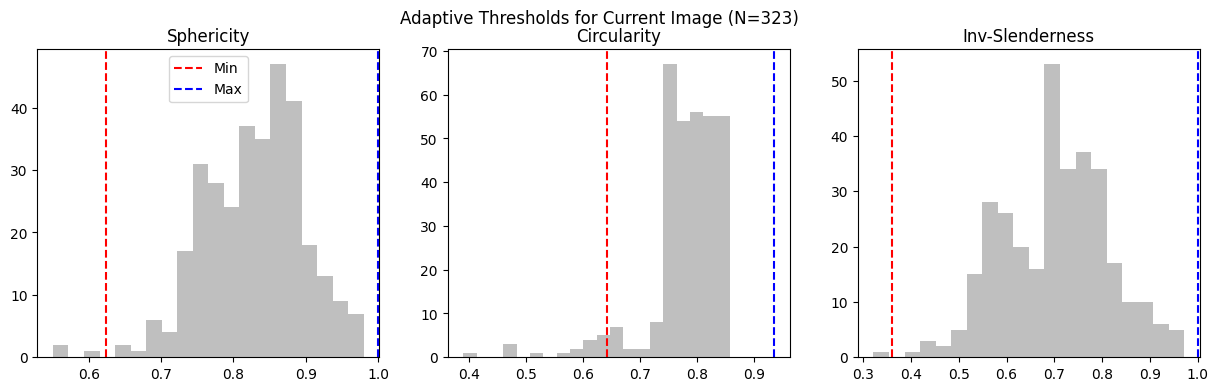

In [ ]:
radius = RADIUS

watershed_config = [0.4, 0.8]
watershed_list = []

for img in label_images:
    particles = detect_particles_dt(
        img,
        particle_radius=radius,
        peak_threshold_ratio=watershed_config[0],
        min_dist_ratio=watershed_config[1]
    )
    watershed_list.append(particles)

In [ ]:
for idx, (test_image, _, _, grid, _) in enumerate(val_dataset):
    name = val_filenames[idx][:-4]
    micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
    label_path = f"{LABEL_DIR}/{name}.png"
    image = Image.open(label_path)
    label_image = np.array(image)

    cropped_micrograph = preprocess_and_crop(micrograph)
    cropped_label_image = preprocess_and_crop(label_image)

    _, ax = plt.subplots(figsize=(12, 12))
    preds = watershed_list[idx]
    coords = [p[:2] for p in preds]
    plot_micrograph_and_labels(ax, cropped_micrograph, cropped_label_image, coords)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
### Analysis on Filterd Particles

In [ ]:
def detect_particles_dt_filtered(prob_map_input, particle_radius=64,
                                 peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                                 show_plots=False):
    # --- 1-4. Preprocessing & Watershed (Same as before) ---
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0
    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return {"valid": [], "area_filtered": [], "shape_filtered": []}

    distance = ndi.distance_transform_edt(binary_mask)
    local_max_coords = peak_local_max(distance, min_distance=int(particle_radius * min_dist_ratio),
                                      labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)

    # --- 5. Initial Area Filtering ---
    expected_area = np.pi * (particle_radius ** 2)
    min_area, max_area = expected_area * 0.3, expected_area * 2.0
    regions = regionprops(labels)

    candidates = []
    area_filtered = []
    m_sp, m_cr, m_isd = [], [], []

    for region in regions:
        cy, cx = region.centroid
        if not (min_area <= region.area <= max_area):
            # changed) Collect particles rejected by size
            area_filtered.append([int(cx), int(cy)])
            continue

        sp, cr, isd = calculate_shape_metrics(region)
        candidates.append({'region': region, 'metrics': (sp, cr, isd)})
        m_sp.append(sp); m_cr.append(cr); m_isd.append(isd)

    if not candidates:
        return {"valid": [], "area_filtered": area_filtered, "shape_filtered": []}

    # --- 6. Robust Adaptive Thresholding (MAD) ---
    def get_mad_range(data, z_thresh=3.0):
        arr = np.array(data)
        med = np.median(arr)
        mad = np.median(np.abs(arr - med))
        if mad == 0: return np.min(arr), np.max(arr)
        low = med - (z_thresh * mad / 0.6745)
        high = med + (z_thresh * mad / 0.6745)
        return max(0.0, low), min(1.0, high)

    t_sp = get_mad_range(m_sp)
    t_cr = get_mad_range(m_cr)
    t_isd = get_mad_range(m_isd)

    # --- 8. Final Categorization ---
    valid = []
    shape_filtered = []
    boundary_margin = 40

    for cand in candidates:
        sp, cr, isd = cand['metrics']
        region = cand['region']
        cy, cx = region.centroid

        # Check Adaptive Thresholds
        if (t_sp[0] <= sp <= t_sp[1] and
            t_cr[0] <= cr <= t_cr[1] and
            t_isd[0] <= isd <= t_isd[1]):

            # Check Boundary
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                valid.append([int(cx), int(cy), float(prob_map[int(cy), int(cx)])])
            else:
                area_filtered.append([int(cx), int(cy)]) # Boundary rejections treated as area/loc rejection
        else:
            # changed) Collect particles rejected by shape
            shape_filtered.append([int(cx), int(cy)])

    return {
        "valid": valid,
        "area_filtered": area_filtered,
        "shape_filtered": shape_filtered
    }

In [ ]:
def plot_micrograph_filtered(ax, micrograph, labels, particle_dict):
    """
    Plots the results using centered crosses:
    - Red '+': Valid Detections
    - Royalblue 'x': Area Rejections
    - Navy 'x': Shape Rejections
    """
    ax.imshow(micrograph, cmap='gray')
    ax.imshow(labels, cmap='gray', alpha=0.3)

    # 1. Plot Area Filtered (Royalblue Cross)
    if particle_dict['area_filtered']:
        area_pts = np.array(particle_dict['area_filtered'])
        ax.scatter(area_pts[:, 0], area_pts[:, 1], marker='x', color='limegreen',
                   s=100, linewidths=2, label='Area Rejected')

    # 2. Plot Shape Filtered (Navy Cross)
    if particle_dict['shape_filtered']:
        shape_pts = np.array(particle_dict['shape_filtered'])
        ax.scatter(shape_pts[:, 0], shape_pts[:, 1], marker='x', color='navy',
                   s=100, linewidths=2, label='Shape Rejected')

    # 3. Plot Valid (Red Plus)
    if particle_dict['valid']:
        valid_pts = np.array(particle_dict['valid'])
        ax.scatter(valid_pts[:, 0], valid_pts[:, 1], marker='+', color='red',
                   s=150, linewidths=1.5, label='Valid')

    # Handle Legend (prevent duplicate labels)
    handles, labels_lg = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_lg, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', frameon=True)

In [ ]:
# Run detection
watershed_results_full = []
for img in label_images:
    res = detect_particles_dt_filtered(
        img,
        particle_radius=RADIUS,
        peak_threshold_ratio=watershed_config[0],
        min_dist_ratio=watershed_config[1],
        show_plots=False # Set to True to see the histograms
    )
    watershed_results_full.append(res)

In [ ]:
for idx, (test_image, _, _, grid, _) in enumerate(val_dataset):
    name = val_filenames[idx][:-4]
    micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
    label_path = f"{LABEL_DIR}/{name}.png"

    cropped_micrograph = preprocess_and_crop(micrograph)
    cropped_label_image = preprocess_and_crop(np.array(Image.open(label_path)))

    fig, ax = plt.subplots(figsize=(12, 12))

    # Use the dictionary containing all categories
    particle_dict = watershed_results_full[idx]

    plot_micrograph_filtered(ax, cropped_micrograph, cropped_label_image, particle_dict)

    plt.show()

Output hidden; open in https://colab.research.google.com to view.

---

Starting DT-Only Grid Search with Adaptive Shape Filtering...
Config: Thresh=0.4, Dist=0.8


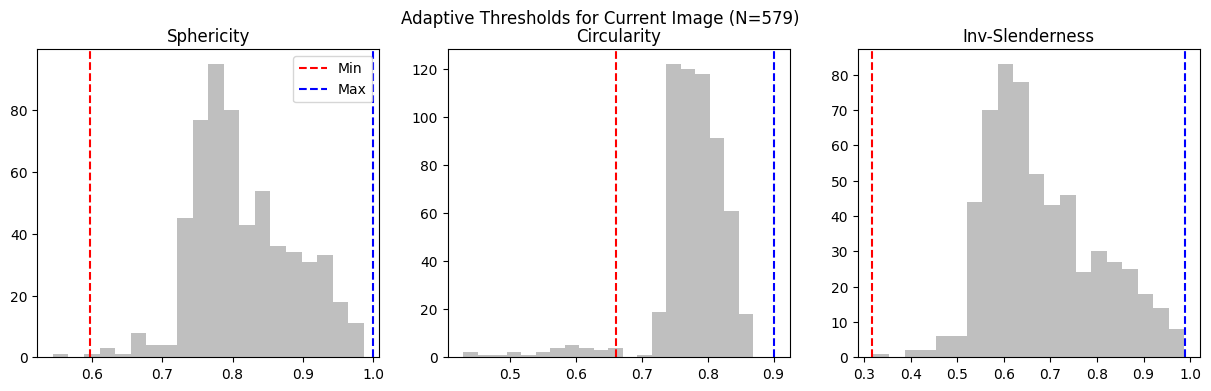

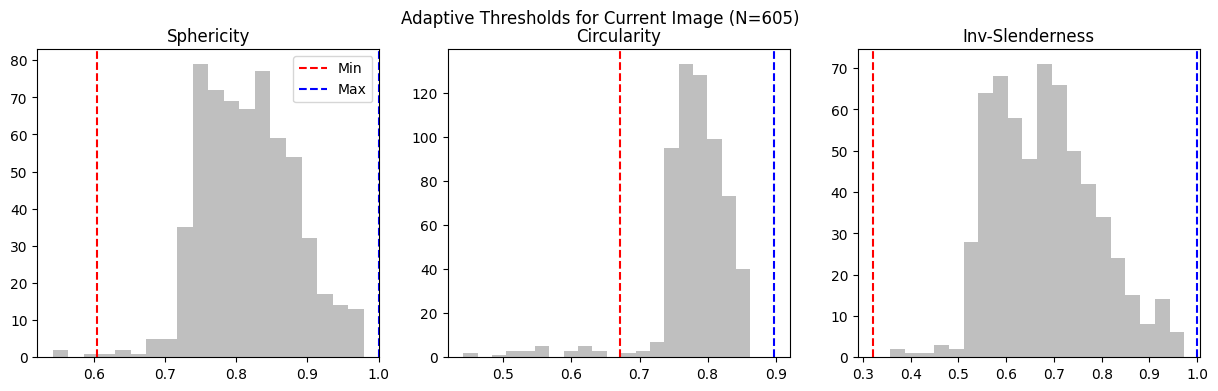

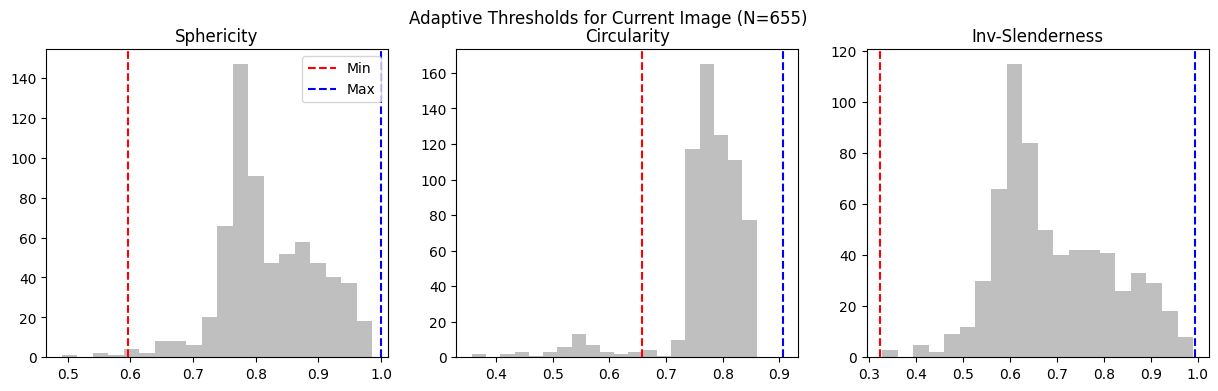

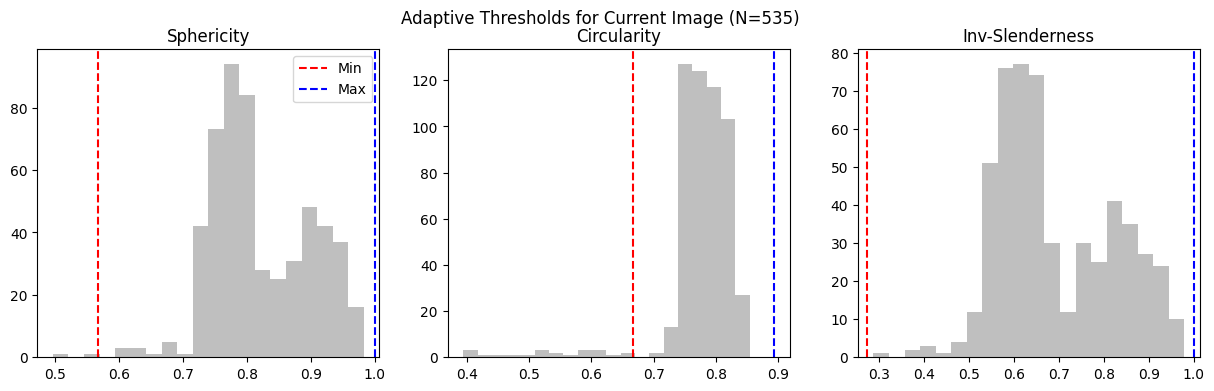

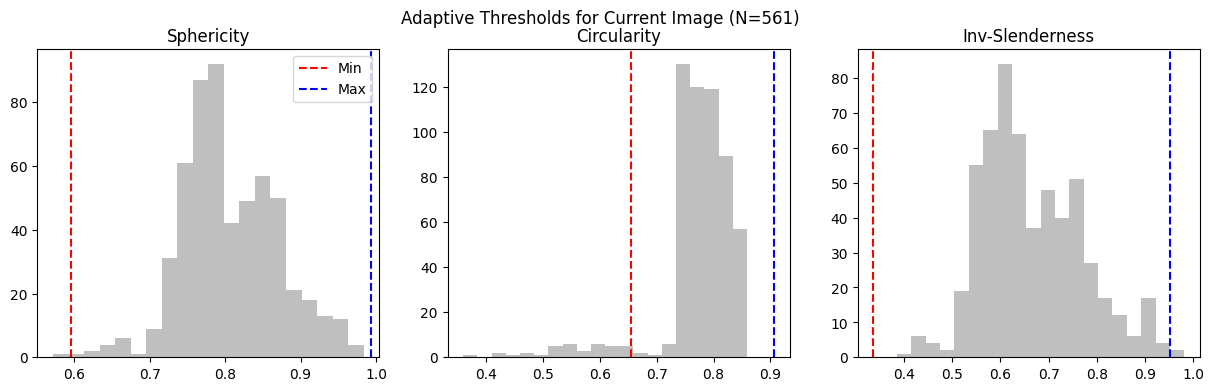

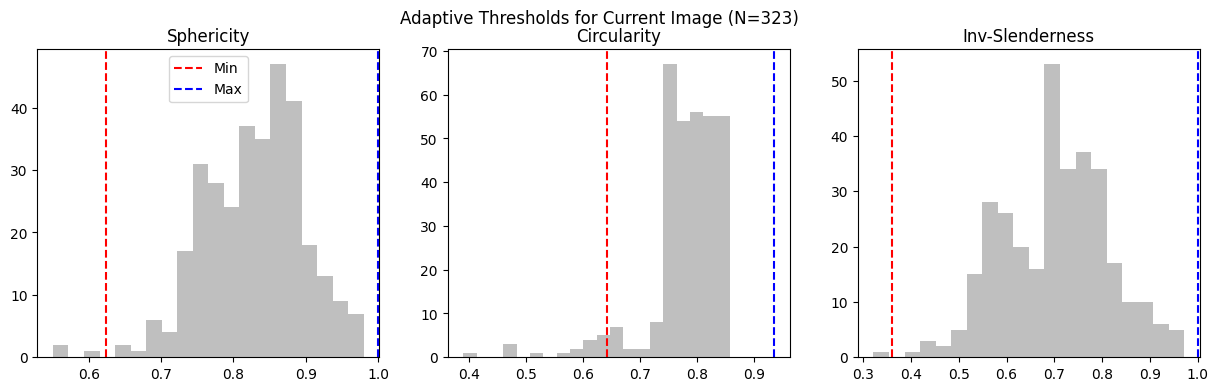

 -> Finished generating 1 candidates.


In [ ]:
# @title DT-Only Grid Search for best hyperparameter
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
# threshold_levels_ratios = [0.5, 0.6, 0.7]
threshold_levels_ratios = [0.4]

# min_dist_ratios = [0.8, 0.9, 1.0]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with Adaptive Shape Filtering...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

for params in param_grid:
    thresh_r, dist_r = params

    print(f"Config: Thresh={thresh_r}, Dist={dist_r}")
    watershed_list = []

    for img in label_images:
        particles = detect_particles_dt(
            img,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r
        )
        watershed_list.append(particles)

    watershed_list_all.append(watershed_list)
    watershed_config.append((thresh_r, dist_r))

print(f" -> Finished generating {len(watershed_list_all)} candidates.")

In [ ]:
# @title Visualize DT-Only Results (Sequential)
import os

# 1. Define Range (Sequential, No Random)
selected_indices = range(len(val_filenames))

print(f"Visualizing {len(selected_indices)} images...")

# 2. Iterate through Configs
for i, ws_list in enumerate(watershed_list_all):
    # DT-Only Config: (thresh, dist, solid)
    cfg = watershed_config[i]

    print(f"\n{'='*20} Param Val: Thresh={cfg[0]}, Dist={cfg[1]} {'='*20}")

    for idx in selected_indices:
        # --- logic: name = val_filenames[idx][:-4] ---
        name = val_filenames[idx][:-4]

        # 1. Load Background (Micrograph)
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
        if os.path.exists(micrograph_path):
            micrograph = np.load(micrograph_path)
            bg_image = preprocess_and_crop(micrograph)
        else:
            print(f"Warning: {name}.npy not found.")
            continue

        # 2. Load Label (Ground Truth)
        label_path = f"{LABEL_DIR}/{name}.png"
        if os.path.exists(label_path):
            image = Image.open(label_path)
            lbl_raw = np.array(image)
            current_label_image = preprocess_and_crop(lbl_raw)
        else:
            current_label_image = np.zeros_like(bg_image) # Fallback

        # 3. Get Predictions
        preds = ws_list[idx]
        coords = [p[:2] for p in preds]

        # 4. Plot
        _, ax = plt.subplots(figsize=(12, 12))
        # Pass the dynamically loaded label image
        plot_micrograph_and_labels(ax, bg_image, current_label_image, coords)

        plt.title(f"Img {idx} ({name}) | Particles: {len(coords)} (Thresh={cfg[0]}, Dist={cfg[1]})")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# @title DT-Only Grid Search: Evaluate & Score
import torch
import os
import json

# Metrics Helper
def evaluate_detection_robust(iou_matrices, iou_threshold=0.5):
    tp_total = 0; fp_total = 0; fn_total = 0
    for iou_matrix in iou_matrices:
        n_gt, n_pred = iou_matrix.shape
        if n_gt == 0 and n_pred == 0: continue
        if n_gt > 0 and n_pred == 0: fn_total += n_gt; continue
        if n_gt == 0 and n_pred > 0: fp_total += n_pred; continue

        max_vals, _ = torch.max(iou_matrix, dim=1)
        detected_mask = max_vals >= iou_threshold
        tp = torch.sum(detected_mask).item()
        tp_total += tp
        fn_total += (n_gt - tp)
        fp_total += (n_pred - tp)

    epsilon = 1e-6
    precision = tp_total / (tp_total + fp_total + epsilon)
    recall = tp_total / (tp_total + fn_total + epsilon)
    return precision, recall

# Main Eval Loop
width = RADIUS * 2
watershed_scores = []

print("Evaluating DT-Only Results...")

for i, ws_list in enumerate(watershed_list_all):
    cfg = watershed_config[i] # (thresh, dist)

    iou_matrices = []
    gt_full = []
    pred_full = []
    scores_list = []

    for idx, gt in enumerate(gts):
        gt_boxes = centers_to_boxes(np.array(gt), width, width)
        gt_full.append(gt_boxes)

        preds = ws_list[idx]
        if len(preds) > 0:
            coords = np.array([p[:2] for p in preds])
            sc = torch.tensor([p[2] for p in preds], dtype=torch.float32)
            pred_boxes = centers_to_boxes(coords, width, width)
        else:
            pred_boxes = torch.empty((0, 4))
            sc = torch.tensor([], dtype=torch.float32)

        pred_full.append(pred_boxes)
        scores_list.append(sc)

        iou_matrix = calculate_iou_torchvision(gt_boxes, pred_boxes)
        iou_matrices.append(iou_matrix)

    # 1. F-Beta
    precision, recall = evaluate_detection_robust(iou_matrices, iou_threshold=0.5)
    f_beta = f_beta_score(precision, recall, beta=1)

    # 2. mAP
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    try:
        mAP_value = calculate_mAP_multiple_images(gt_full, pred_full, scores_list, iou_thresholds)
        map_val = mAP_value.item()
    except:
        map_val = 0.0

    print(f"Cfg: {cfg} | F1: {f_beta:.4f}, mAP: {map_val:.4f}")
    watershed_scores.append((f_beta, map_val))

# Save Best
if len(watershed_scores) > 0:
    best_idx = max(range(len(watershed_scores)), key=lambda i: watershed_scores[i][0])
    best_cfg = watershed_config[best_idx]

    best_res = {
        "method": "dt_only_no_ar",
        "thresh": best_cfg[0],
        "dist": best_cfg[1],
        "f_score": watershed_scores[best_idx][0],
        "map": watershed_scores[best_idx][1]
    }

    print("\n--- BEST CONFIGURATION (DT ONLY - NO AR) ---")
    print(best_res)

    # 1. Save to local content first (Current Directory)
    local_file = 'best_watershed_params.json'
    with open(local_file, 'w') as f:
        json.dump(best_res, f, indent=4)
    print(f"✅ Saved locally to: {local_file}")

    # 2. Copy to RESULT_DIR using shell command
    # We put quotes "" around the path in case RESULT_DIR has spaces
    !cp {local_file} "{RESULT_DIR}"

    print(f"✅ Copied to: {RESULT_DIR}/{local_file}")

Evaluating DT-Only Results...
Cfg: (0.4, 0.8) | F1: 0.9745, mAP: 0.8455

--- BEST CONFIGURATION (DT ONLY - NO AR) ---
{'method': 'dt_only_no_ar', 'thresh': 0.4, 'dist': 0.8, 'f_score': 0.9744772250380701, 'map': 0.8455223441123962}
✅ Saved locally to: best_watershed_params.json
✅ Copied to: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_test/10017/unet_eb5_dice_CRF/best_watershed_params.json


## Ending